# Activity 2: Pricing and Spread Models

Through the following code, I first load the datasets, clean and process them.

And then I merge the data together during the Australian trading hours and calculate an iNAV for ndq through that time period.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Load EOD QQQ Data from US Exchange

Here I load and process US QQQ data. This data is provided using US Eastern Time the close price at the end of each day for a year.

I will only use the most recent close price as a measure of the March 19 EOD Net Asset Value for the ETF in the US.

In [2]:
usqqqeod = pd.read_csv("US ETFs Nasdaq 100 20250320 EOD 1Yr.csv", skiprows=1)[:1820]
# usqqqeod["Date-Time2"] = pd.to_datetime(usqqqeod["Date-Time"])
# usqqqeod['AusTime'] = usqqqeod['Date-Time2'].dt.time
# usqqqeod['Date-Time3'] = usqqqeod['Date-Time2'].dt.tz_convert('UTC')
# usqqqeod['UTCTime'] = usqqqeod['Date-Time3'].dt.time
print(usqqqeod.shape)
print(usqqqeod.columns)
# usqqqeod['Trade Date'] = pd.to_datetime(usqqqeod['Trade Date'])
usqqqeod['Universal Close Price'] = usqqqeod['Universal Close Price'].replace({',': ''}, regex=True).astype(float)
usqqqeod['VWAP'] = usqqqeod['VWAP'].replace({',': ''}, regex=True).astype(float)

usqqqeod.head()

(1820, 6)
Index(['Trade Date', 'RIC', 'Ticker', 'Universal Close Price', 'VWAP',
       'Volume'],
      dtype='object')


,Trade Date,RIC,Ticker,Universal Close Price,VWAP,Volume
0,21/03/2024,QQQ.N,QQQ,445.800,447.6347,"884,838"
1,22/03/2024,QQQ.N,QQQ,446.180,446.2129,"636,211"
2,25/03/2024,QQQ.N,QQQ,444.805,444.8810,"624,839"
3,26/03/2024,QQQ.N,QQQ,443.330,445.4064,"737,154"
4,27/03/2024,QQQ.N,QQQ,444.940,443.4729,"861,916"


In [50]:
usqqqeod.tail()

,Trade Date,RIC,Ticker,Universal Close Price,VWAP,Volume
1815,13/03/2025,NQc1,NQ,19249.00,19397.29141,"761,160"
1816,14/03/2025,NQc1,NQ,19712.00,19576.01419,"742,663"
1817,17/03/2025,NQc1,NQ,19831.75,19756.05061,"584,953"
1818,18/03/2025,NQc1,NQ,19496.75,19579.45043,"360,195"
1819,19/03/2025,NQc1,NQ,19746.75,19645.15105,"210,518"


In [19]:
usqqqeod[1819:1820]

,Trade Date,RIC,Ticker,Universal Close Price,VWAP,Volume
1819,19/03/2025,NQc1,NQ,"19,746.75","19,645.15105","210,518"


### Load NDQ Data from AU Exchange

I load and process the NDQ ETF data from AU Exchanges. I filter this data for all data points within active trading hours between 10am and 4pm on March 20 in Sydney. The trading day in Australia starts while the trading day in the US is closed.

In [3]:
ausndq = pd.read_csv("AU ETF NDQ 20250320 Intraday 5Sec.csv")
ausndq["Date-Time2"] = pd.to_datetime(ausndq["Date-Time"])
ausndq['AusTime'] = ausndq['Date-Time2'].dt.time
ausndq['Date-Time3'] = ausndq['Date-Time2'].dt.tz_convert('UTC')
ausndq['UTCTime'] = ausndq['Date-Time3'].dt.time
from datetime import time
start_time = time(10, 0, 0)  # 10:10:00 AM
end_time = time(16, 0, 0)     # 16:00:00 PM
ausndq = ausndq[(ausndq['AusTime'] >= start_time) & (ausndq['AusTime'] <= end_time)]
print(ausndq.shape)
print(ausndq.columns)
ausndq.head()

(4321, 38)
Index(['#RIC', 'Alias Underlying RIC', 'Domain', 'Date-Time', 'Type', 'Open',
       'High', 'Low', 'Last', 'Volume', 'No. Trades', 'Open Bid', 'High Bid',
       'Low Bid', 'Close Bid', 'No. Bids', 'Open Ask', 'High Ask', 'Low Ask',
       'Close Ask', 'No. Asks', 'Open Bid Size', 'High Bid Size',
       'Low Bid Size', 'Close Bid Size', 'Open Ask Size', 'High Ask Size',
       'Low Ask Size', 'Close Ask Size', 'Open Mid Price', 'High Mid Price',
       'Low Mid Price', 'Close Mid Price', 'Filter', 'Date-Time2', 'AusTime',
       'Date-Time3', 'UTCTime'],
      dtype='object')


,#RIC,Alias Underlying RIC,Domain,Date-Time,Type,Open,High,Low,Last,Volume,...,Close Ask Size,Open Mid Price,High Mid Price,Low Mid Price,Close Mid Price,Filter,Date-Time2,AusTime,Date-Time3,UTCTime
7200,NDQ.AUX,NaN,Market Price,2025-03-20T10:00:00.000000000+11,Intraday 5Sec,NaN,NaN,NaN,NaN,NaN,...,8248,46.280,46.280,46.27,46.270,Opening Auction,2025-03-20 10:00:00+11:00,10:00:00,2025-03-19 23:00:00+00:00,23:00:00
7201,NDQ.AUX,NaN,Market Price,2025-03-20T10:00:05.000000000+11,Intraday 5Sec,NaN,NaN,NaN,NaN,NaN,...,2000,46.280,46.325,46.28,46.325,CLOB,2025-03-20 10:00:05+11:00,10:00:05,2025-03-19 23:00:05+00:00,23:00:05
7202,NDQ.AUX,NaN,Market Price,2025-03-20T10:00:10.000000000+11,Intraday 5Sec,46.29,46.3,46.29,46.3,8569.0,...,1,46.305,46.305,46.30,46.300,CLOB,2025-03-20 10:00:10+11:00,10:00:10,2025-03-19 23:00:10+00:00,23:00:10
7203,NDQ.AUX,NaN,Market Price,2025-03-20T10:00:15.000000000+11,Intraday 5Sec,NaN,NaN,NaN,NaN,NaN,...,1,NaN,NaN,NaN,NaN,CLOB,2025-03-20 10:00:15+11:00,10:00:15,2025-03-19 23:00:15+00:00,23:00:15
7204,NDQ.AUX,NaN,Market Price,2025-03-20T10:00:20.000000000+11,Intraday 5Sec,NaN,NaN,NaN,NaN,NaN,...,1,46.305,46.305,46.30,46.300,CLOB,2025-03-20 10:00:20+11:00,10:00:20,2025-03-19 23:00:20+00:00,23:00:20


In [24]:
pd.to_datetime(ausndq['Date-Time']).describe()

count                         4321
mean     2025-03-20 13:00:00+11:00
min      2025-03-20 10:00:00+11:00
25%      2025-03-20 11:30:00+11:00
50%      2025-03-20 13:00:00+11:00
75%      2025-03-20 14:30:00+11:00
max      2025-03-20 16:00:00+11:00
Name: Date-Time, dtype: object

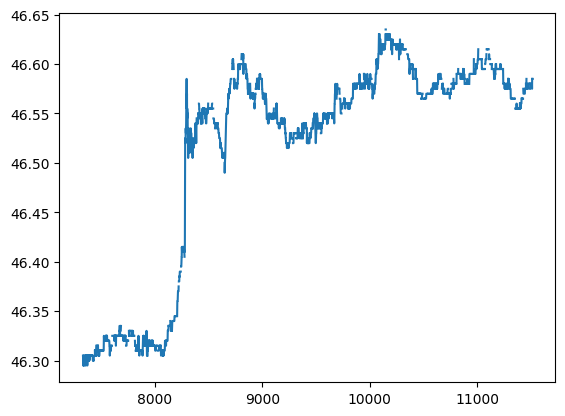

In [3]:
plt.plot(ausndq['Close Mid Price'])

### Load AUD/USD Foreign Exchange Rate

I load and process the AUD / USD exchange rate for March 19-20. The time zone on this data is in UTC and might be set in London or something like that.

In [4]:
audusd = pd.read_csv("FX AUD USD 20250319-20 Intraday 5Sec.csv")
audusd["Date-Time2"] = pd.to_datetime(audusd["Date-Time"])
audusd['Date-Time3'] = audusd['Date-Time2'].dt.tz_convert('UTC')
audusd['UTCTime'] = audusd['Date-Time3'].dt.time
print(audusd.shape)
print(audusd.columns)
audusd.head()

(34560, 37)
Index(['#RIC', 'Alias Underlying RIC', 'Domain', 'Date-Time', 'GMT Offset',
       'Type', 'Open', 'High', 'Low', 'Last', 'Volume', 'No. Trades',
       'Open Bid', 'High Bid', 'Low Bid', 'Close Bid', 'No. Bids', 'Open Ask',
       'High Ask', 'Low Ask', 'Close Ask', 'No. Asks', 'Open Bid Size',
       'High Bid Size', 'Low Bid Size', 'Close Bid Size', 'Open Ask Size',
       'High Ask Size', 'Low Ask Size', 'Close Ask Size', 'Open Mid Price',
       'High Mid Price', 'Low Mid Price', 'Close Mid Price', 'Date-Time2',
       'Date-Time3', 'UTCTime'],
      dtype='object')


,#RIC,Alias Underlying RIC,Domain,Date-Time,GMT Offset,Type,Open,High,Low,Last,...,High Ask Size,Low Ask Size,Close Ask Size,Open Mid Price,High Mid Price,Low Mid Price,Close Mid Price,Date-Time2,Date-Time3,UTCTime
0,AUD=,NaN,Market Price,2025-03-19T00:00:00.000000000Z,0,Intraday 5Sec,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.63620,0.63620,0.63610,0.63610,2025-03-19 00:00:00+00:00,2025-03-19 00:00:00+00:00,00:00:00
1,AUD=,NaN,Market Price,2025-03-19T00:00:05.000000000Z,0,Intraday 5Sec,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.63610,0.63615,0.63610,0.63615,2025-03-19 00:00:05+00:00,2025-03-19 00:00:05+00:00,00:00:05
2,AUD=,NaN,Market Price,2025-03-19T00:00:10.000000000Z,0,Intraday 5Sec,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.63615,0.63615,0.63615,0.63615,2025-03-19 00:00:10+00:00,2025-03-19 00:00:10+00:00,00:00:10
3,AUD=,NaN,Market Price,2025-03-19T00:00:15.000000000Z,0,Intraday 5Sec,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.63615,0.63615,0.63615,0.63615,2025-03-19 00:00:15+00:00,2025-03-19 00:00:15+00:00,00:00:15
4,AUD=,NaN,Market Price,2025-03-19T00:00:20.000000000Z,0,Intraday 5Sec,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-03-19 00:00:20+00:00,2025-03-19 00:00:20+00:00,00:00:20


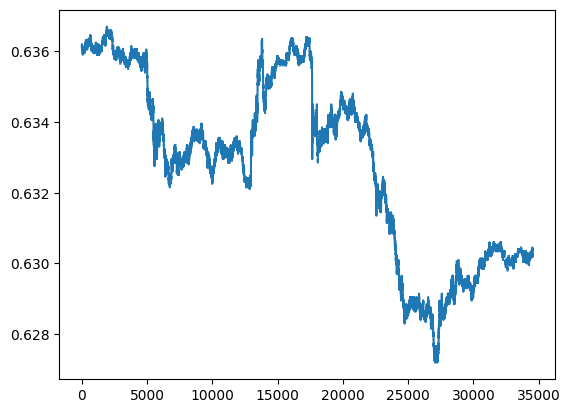

In [5]:
plt.plot(audusd['Close Mid Price'])

### Calculate a Conversion Factor

This conversion factor is simulating the use of the previous days US EOD NAV and then adjusting to the AU NDQ ETF creating a ratio that mimics what we learned in class during Lecture 5.

In that process we use the previous days US NAV. Convert to USD, update by the change in the futures and then convert back to AUD. We do the same process here using this conversion factor

In [5]:
import warnings; warnings.filterwarnings("ignore")
qqq_eod_price = float(usqqqeod[1819:]["Universal Close Price"])

ndq_start_price = float(ausndq.head(1)['Close Mid Price'])
audusd_start_price = float(audusd.head(1)['Close Mid Price'])

ndq_start_price, qqq_eod_price, audusd_start_price


(46.27, 19746.75, 0.6361)

In [6]:
conversion_factor = ndq_start_price / (qqq_eod_price * audusd_start_price)
conversion_factor

0.00368365099061203

### Load NQ Future Data from US Exchange

I load and process the futures from US exchanges. We use the futures value as a proxy in the process of calculating an iNAV. The change in futures value helps indicate to us the movement of the actualy underlying NDQ

In [7]:
usfuturenq = pd.read_csv("US Future NQ 20250319 Intraday 5Sec.csv")
usfuturenq["Date-Time2"] = pd.to_datetime(usfuturenq["Date-Time"])
usfuturenq['Date-Time3'] = usfuturenq['Date-Time2'].dt.tz_convert('UTC')
usfuturenq['UTCTime'] = usfuturenq['Date-Time3'].dt.time
print(usfuturenq.shape)
print(usfuturenq.columns)
usfuturenq.head()

(17280, 36)
Index(['#RIC', 'Alias Underlying RIC', 'Domain', 'Date-Time', 'Type', 'Open',
       'High', 'Low', 'Last', 'Volume', 'No. Trades', 'Open Bid', 'High Bid',
       'Low Bid', 'Close Bid', 'No. Bids', 'Open Ask', 'High Ask', 'Low Ask',
       'Close Ask', 'No. Asks', 'Open Bid Size', 'High Bid Size',
       'Low Bid Size', 'Close Bid Size', 'Open Ask Size', 'High Ask Size',
       'Low Ask Size', 'Close Ask Size', 'Open Mid Price', 'High Mid Price',
       'Low Mid Price', 'Close Mid Price', 'Date-Time2', 'Date-Time3',
       'UTCTime'],
      dtype='object')


,#RIC,Alias Underlying RIC,Domain,Date-Time,Type,Open,High,Low,Last,Volume,...,High Ask Size,Low Ask Size,Close Ask Size,Open Mid Price,High Mid Price,Low Mid Price,Close Mid Price,Date-Time2,Date-Time3,UTCTime
0,NQc1,NQH25,Market Price,2025-03-19T00:00:00.000000000-05,Intraday 5Sec,NaN,NaN,NaN,NaN,NaN,...,4,1,1,19528.875,19530.500,19528.500,19529.625,2025-03-19 00:00:00-05:00,2025-03-19 05:00:00+00:00,05:00:00
1,NQc1,NQH25,Market Price,2025-03-19T00:00:05.000000000-05,Intraday 5Sec,19530.25,19530.25,19530.25,19530.25,1.0,...,3,1,2,19529.625,19530.625,19529.000,19529.750,2025-03-19 00:00:05-05:00,2025-03-19 05:00:05+00:00,05:00:05
2,NQc1,NQH25,Market Price,2025-03-19T00:00:10.000000000-05,Intraday 5Sec,NaN,NaN,NaN,NaN,NaN,...,2,1,2,19529.750,19530.500,19529.625,19529.750,2025-03-19 00:00:10-05:00,2025-03-19 05:00:10+00:00,05:00:10
3,NQc1,NQH25,Market Price,2025-03-19T00:00:15.000000000-05,Intraday 5Sec,NaN,NaN,NaN,NaN,NaN,...,4,1,1,19529.625,19529.875,19529.000,19529.875,2025-03-19 00:00:15-05:00,2025-03-19 05:00:15+00:00,05:00:15
4,NQc1,NQH25,Market Price,2025-03-19T00:00:20.000000000-05,Intraday 5Sec,NaN,NaN,NaN,NaN,NaN,...,2,1,1,19529.875,19529.875,19529.500,19529.875,2025-03-19 00:00:20-05:00,2025-03-19 05:00:20+00:00,05:00:20


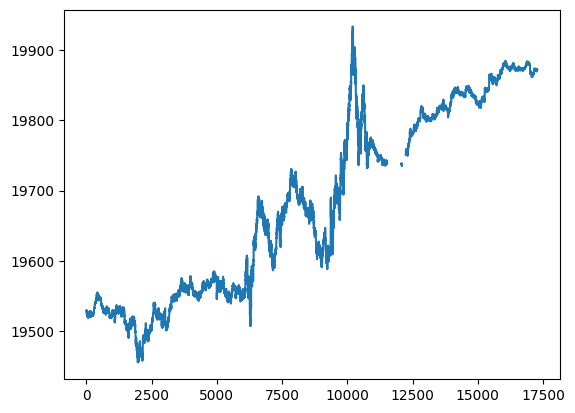

In [7]:
plt.plot(usfuturenq['Close Mid Price'])

### Merge Datasets and Calculate iNAV

I merge the datasets and align them on the same time zone using the UTC time zone. All of the data is filtered to be within AUS exchange trading hours already. 

I then calculate the iNAV at each point by multiplying the futures value by the aud/usd exchange rate by the original conversion factor

In [8]:
def add_suffix(df, suffix):
    df.columns = [f"{col}_{suffix}" for col in df.columns]
    return df

audusd = add_suffix(audusd, "audusd")
usfuturenq = add_suffix(usfuturenq, "nq")
ausndq = add_suffix(ausndq, 'ndq')

In [9]:
spotprices = pd.merge(audusd, usfuturenq, left_on="UTCTime_audusd", right_on="UTCTime_nq", how="inner")
cols = ["#RIC_audusd", "#RIC_nq", "UTCTime_audusd", "UTCTime_nq", "Type_nq", "Close Mid Price_audusd", "Close Mid Price_nq"]

print(spotprices.shape)
spotprices[cols].head()

(34560, 73)


,#RIC_audusd,#RIC_nq,UTCTime_audusd,UTCTime_nq,Type_nq,Close Mid Price_audusd,Close Mid Price_nq
0,AUD=,NQc1,00:00:00,00:00:00,Intraday 5Sec,0.63610,19829.250
1,AUD=,NQc1,00:00:05,00:00:05,Intraday 5Sec,0.63615,19826.000
2,AUD=,NQc1,00:00:10,00:00:10,Intraday 5Sec,0.63615,19825.875
3,AUD=,NQc1,00:00:15,00:00:15,Intraday 5Sec,0.63615,19824.375
4,AUD=,NQc1,00:00:20,00:00:20,Intraday 5Sec,NaN,19817.750


In [26]:
compare = pd.merge(spotprices, ausndq, left_on = "UTCTime_audusd", right_on = "UTCTime_ndq", how="inner")
print(compare.shape)
cols = ["Date-Time3_ndq", "UTCTime_audusd", "AusTime_ndq", "Close Mid Price_audusd", "Close Mid Price_nq", "Close Mid Price_ndq"]
compareSpecific = compare[cols].sort_values(by="AusTime_ndq")
compareSpecific.head()


(8642, 111)


,Date-Time3_ndq,UTCTime_audusd,AusTime_ndq,Close Mid Price_audusd,Close Mid Price_nq,Close Mid Price_ndq
3601,2025-03-19 23:00:00+00:00,23:00:00,10:00:00,0.63580,19805.125,46.270
7922,2025-03-19 23:00:00+00:00,23:00:00,10:00:00,0.63015,19805.125,46.270
3602,2025-03-19 23:00:05+00:00,23:00:05,10:00:05,0.63580,19808.375,46.325
7923,2025-03-19 23:00:05+00:00,23:00:05,10:00:05,0.63010,19808.375,46.325
3603,2025-03-19 23:00:10+00:00,23:00:10,10:00:10,0.63580,19804.000,46.300


In [32]:
compareSpecific['iNAV'] = compareSpecific['Close Mid Price_audusd'] * compareSpecific['Close Mid Price_nq'] * conversion_factor
compareSpecific.head()

,Date-Time3_ndq,UTCTime_audusd,AusTime_ndq,Close Mid Price_audusd,Close Mid Price_nq,Close Mid Price_ndq,iNAV
3601,2025-03-19 23:00:00+00:00,23:00:00,10:00:00,0.63580,19805.125,46.270,46.384896
7922,2025-03-19 23:00:00+00:00,23:00:00,10:00:00,0.63015,19805.125,46.270,45.972699
3602,2025-03-19 23:00:05+00:00,23:00:05,10:00:05,0.63580,19808.375,46.325,46.392508
7923,2025-03-19 23:00:05+00:00,23:00:05,10:00:05,0.63010,19808.375,46.325,45.976595
3603,2025-03-19 23:00:10+00:00,23:00:10,10:00:10,0.63580,19804.000,46.300,46.382261


### Evaluate iNAV Calculation

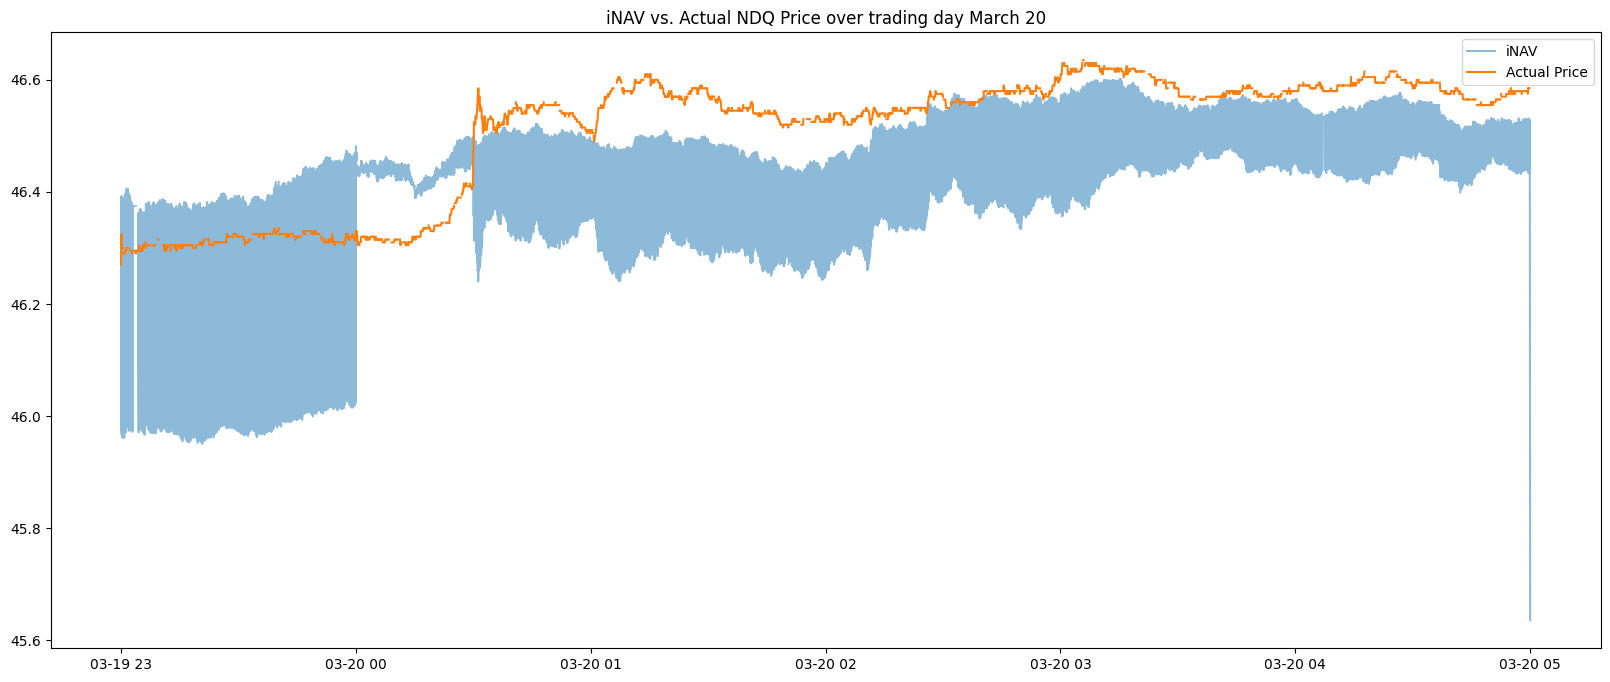

In [31]:
plt.figure(figsize=(20,8))
plt.plot(compareSpecific['Date-Time3_ndq'], compareSpecific['iNAV'], alpha=0.5, label="iNAV");
plt.plot(compareSpecific['Date-Time3_ndq'], compareSpecific['Close Mid Price_ndq'], label="Actual Price");
plt.legend();
plt.title("iNAV vs. Actual NDQ Price over trading day March 20");

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

compareSpecific = compareSpecific.dropna(subset=["Close Mid Price_ndq", "iNAV"])

# Step 1: Calculate the MAE, MSE, and R² metrics
mae = mean_absolute_error(compareSpecific['Close Mid Price_ndq'], compareSpecific['iNAV'])
mse = mean_squared_error(compareSpecific['Close Mid Price_ndq'], compareSpecific['iNAV'])
r2 = r2_score(compareSpecific['Close Mid Price_ndq'], compareSpecific['iNAV'])

# Step 2: Create a new DataFrame to hold the metrics
metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'R²'],
    'Value': [mae, mse, r2]
})

metrics_df

,Metric,Value
0,MAE,0.134225
1,MSE,0.027371
2,R²,-1.424434
